# Projeto — Estatística Aplicada com dados de jogadores FIFA
## Fase 2

**Aluno(a):** Italo Infantini Filho  
**Disciplina:** Estatística Aplicada  
**Professor:** Hélio Radke Bittencourt

Este notebook corresponde à segunda entrega do projeto e utiliza a mesma base FIFA da Fase 1, sem alterar os nomes das variáveis.

## 1. Bibliotecas

Usaremos `ggplot2`, `dplyr` e `scales`, mantendo a mesma configuração da Fase 1.

In [14]:
pacotes <- c("ggplot2", "dplyr", "scales")

novos <- pacotes[!(pacotes %in% rownames(installed.packages()))]
if (length(novos) > 0) {
  install.packages(novos, repos = "https://cloud.r-project.org")
}

invisible(lapply(pacotes, library, character.only = TRUE))
options(scipen = 999)


## 2. Leitura do banco de dados

O arquivo é lido diretamente do repositório oficial do curso. O endereço `blob` é mantido como referência e a leitura é feita pelo endereço **Raw** correspondente ao mesmo arquivo. A opção `check.names = FALSE` preserva nomes como `international_reputation(1-5)`.

In [15]:
url_github <- paste0(
  "https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/",
  "Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv"
)

url_csv <- paste0(
  "https://github.com/filipezabala/pucrs-tecnologo-bd/raw/refs/heads/main/dados/",
  "Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv"
)

df <- read.table(
  url_csv,
  header = TRUE,
  sep = ";",
  dec = ".",
  fileEncoding = "latin1",
  stringsAsFactors = FALSE,
  check.names = FALSE,
  quote = "",
  comment.char = ""
)

dim(df)
names(df)
head(df)


[1] 718  30

[1] "id"                            "name"                         
 [3] "full_name"                     "overall_rating"               
 [5] "value_euro"                    "wage_euro"                    
 [7] "nationality"                   "national_team"                
 [9] "club_team"                     "age"                          
[11] "height_cm"                     "weight_kgs"                   
[13] "international_reputation(1-5)" "weak_foot(1-5)"               
[15] "skill_moves(1-5)"              "club_rating"                  
[17] "Goleiro"                       "Zagueiro"                     
[19] "Meio"                          "Atacante"                     
[21] "crossing"                      "finishing"                    
[23] "heading_accuracy"              "short_passing"                
[25] "dribbling"                     "jumping"                      
[27] "strength"                      "long_shots"                   
[29] "aggression"                    "GK_reflexes"

,id,name,full_name,overall_rating,value_euro,wage_euro,nationality,national_team,club_team,age,⋯,crossing,finishing,heading_accuracy,short_passing,dribbling,jumping,strength,long_shots,aggression,GK_reflexes
,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,158023,Messi,Lionel Andrés Messi Cuccittini,94,110500000,565000,Argentina,Argentina,FC Barcelona,31,⋯,86,95,70,92,97,68,66,94,48,8
2,153079,Aguero,Sergio Leonel Agüero del Castillo,89,64500000,300000,Argentina,Argentina,Manchester City,30,⋯,70,93,77,81,89,81,73,83,65,14
3,211110,Dybala,Paulo Bruno Exequiel Dybala,89,89000000,205000,Argentina,Argentina,Juventus,25,⋯,82,84,68,87,92,75,65,88,48,8
4,201399,Icardi,Mauro Emanuel Icardi Rivero,87,64500000,130000,Argentina,Argentina,Inter,26,⋯,46,91,91,73,77,94,76,70,56,9
5,226226,Lo Celso,Giovani Lo Celso,82,30000000,83000,Argentina,Argentina,Real Betis,22,⋯,75,77,59,82,84,64,69,76,65,14
6,199667,Funes Mori,José Ramiro Funes Mori,77,8500000,28000,Argentina,Argentina,Villarreal CF,28,⋯,66,40,79,70,63,77,78,56,83,7


### 2.1 Verificação inicial

Confirmamos a dimensão da base e verificamos valores ausentes e duplicidades antes das análises.

In [16]:
cat("Número de linhas:", nrow(df), "\n")
cat("Número de colunas:", ncol(df), "\n")
cat("Células com NA:", sum(is.na(df)), "\n")
cat("IDs duplicados:", sum(duplicated(df$id)), "\n")
cat("Linhas duplicadas:", sum(duplicated(df)), "\n")

str(df)

stopifnot(nrow(df) == 718)
stopifnot(ncol(df) == 30)
stopifnot(sum(is.na(df)) == 0)


Número de linhas: 718 
Número de colunas: 30 
Células com NA: 0 
IDs duplicados: 0 
Linhas duplicadas: 0 
'data.frame':	718 obs. of  30 variables:
 $ id                           : int  158023 153079 211110 201399 226226 199667 212616 216816 183892 231478 ...
 $ name                         : chr  "Messi" "Aguero" "Dybala" "Icardi" ...
 $ full_name                    : chr  "Lionel Andrés Messi Cuccittini" "Sergio Leonel Agüero del Castillo" "Paulo Bruno Exequiel Dybala" "Mauro Emanuel Icardi Rivero" ...
 $ overall_rating               : int  94 89 89 87 82 77 77 78 79 79 ...
 $ value_euro                   : int  110500000 64500000 89000000 64500000 30000000 8500000 12000000 15000000 8500000 18000000 ...
 $ wage_euro                    : int  565000 300000 205000 130000 83000 28000 27000 53000 19000 54000 ...
 $ nationality                  : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ national_team                : chr  "Argentina" "Argentina" "Argentina" "Argentina" 

# Fase 2 — Probabilidades, Inferência e Regressão

Esta segunda etapa dá continuidade à Fase 1 **sem alterar os nomes das variáveis do banco de dados**. O banco continua sendo lido diretamente do arquivo oficial disponibilizado no GitHub.

Os objetivos desta fase são:

1. calcular probabilidades incondicionais e condicionais;
2. construir e interpretar intervalos de confiança;
3. realizar testes de hipóteses para médias populacionais;
4. ajustar e diagnosticar um modelo de regressão;
5. transformar os principais achados das duas fases em três manchetes de linguagem não técnica.

> **Observação metodológica.** Intervalos de confiança e testes de hipóteses pressupõem, para sua interpretação inferencial usual, que a amostra seja representativa e que as observações possam ser tratadas como independentes. A base FIFA é observacional e não resulta necessariamente de uma amostragem aleatória simples de todos os jogadores de futebol. Portanto, as conclusões inferenciais abaixo devem ser entendidas dentro desse enquadramento didático e da população de referência implícita no projeto.

## 9. Probabilidades incondicionais e condicionais

Serão utilizadas duas variáveis já presentes na base, mantendo seus nomes originais:

- `overall_rating`;
- `international_reputation(1-5)`.

Definimos os eventos:

\[
A = \{\texttt{overall\_rating} \ge 80\}
\]

e

\[
B = \{\texttt{international\_reputation(1-5)} \ge 3\}.
\]

As probabilidades incondicionais são \(P(A)\) e \(P(B)\). Já as condicionais são:

\[
P(A\mid B)=\frac{P(A\cap B)}{P(B)}
\]

e

\[
P(B\mid A)=\frac{P(A\cap B)}{P(A)}.
\]

Como estamos trabalhando com a base observada, essas probabilidades são estimadas por frequências relativas.

In [17]:
evento_A <- df$overall_rating >= 80
evento_B <- df[["international_reputation(1-5)"]] >= 3

n_total <- nrow(df)
n_A <- sum(evento_A)
n_B <- sum(evento_B)
n_AB <- sum(evento_A & evento_B)

stopifnot(n_A > 0, n_B > 0)

p_A <- n_A / n_total
p_B <- n_B / n_total
p_A_dado_B <- n_AB / n_B
p_B_dado_A <- n_AB / n_A

resultado_probabilidades <- data.frame(
  Medida = c(
    "P(overall_rating >= 80)",
    "P(international_reputation(1-5) >= 3)",
    "P(overall_rating >= 80 | international_reputation(1-5) >= 3)",
    "P(international_reputation(1-5) >= 3 | overall_rating >= 80)"
  ),
  Numerador = c(n_A, n_B, n_AB, n_AB),
  Denominador = c(n_total, n_total, n_B, n_A),
  Probabilidade = round(c(p_A, p_B, p_A_dado_B, p_B_dado_A), 4),
  Percentual = round(100 * c(p_A, p_B, p_A_dado_B, p_B_dado_A), 2),
  check.names = FALSE
)

resultado_probabilidades

cat(sprintf(
  "\nInterpretação:\n- %.2f%% dos jogadores possuem overall_rating >= 80.\n",
  100 * p_A
))
cat(sprintf(
  "- %.2f%% possuem international_reputation(1-5) >= 3.\n",
  100 * p_B
))
cat(sprintf(
  "- Entre os jogadores com reputação internacional >= 3, %.2f%% possuem overall_rating >= 80.\n",
  100 * p_A_dado_B
))
cat(sprintf(
  "- Entre os jogadores com overall_rating >= 80, %.2f%% possuem reputação internacional >= 3.\n",
  100 * p_B_dado_A
))

Medida,Numerador,Denominador,Probabilidade,Percentual
<chr>,<int>,<int>,<dbl>,<dbl>
P(overall_rating >= 80),217,718,0.3022,30.22
P(international_reputation(1-5) >= 3),133,718,0.1852,18.52
P(overall_rating >= 80 | international_reputation(1-5) >= 3),115,133,0.8647,86.47
P(international_reputation(1-5) >= 3 | overall_rating >= 80),115,217,0.5300,53.00



Interpretação:
- 30.22% dos jogadores possuem overall_rating >= 80.
- 18.52% possuem international_reputation(1-5) >= 3.
- Entre os jogadores com reputação internacional >= 3, 86.47% possuem overall_rating >= 80.
- Entre os jogadores com overall_rating >= 80, 53.00% possuem reputação internacional >= 3.


### Interpretação das probabilidades

A probabilidade **incondicional** descreve a frequência de um evento na base inteira, sem impor uma condição adicional. Por exemplo, \(P(A)\) responde qual é a proporção de jogadores com `overall_rating` pelo menos 80.

A probabilidade **condicional** restringe o universo de comparação. Assim, \(P(A\mid B)\) responde qual é a proporção de jogadores com `overall_rating` pelo menos 80 **entre aqueles que já possuem** `international_reputation(1-5)` de 3 a 5.

Na Fase 1, 133 dos 718 jogadores estavam nos níveis 3, 4 ou 5 de reputação internacional, o que corresponde a aproximadamente **18,52%** da base. O bloco acima complementa essa informação mostrando como a ocorrência de uma reputação mais alta altera a frequência de avaliações gerais elevadas.

> Uma diferença entre \(P(A)\) e \(P(A\mid B)\) indica associação entre os eventos na base, mas **não demonstra causalidade**.

## 10. Intervalos de confiança para médias

Serão construídos intervalos de confiança de 95% para as médias de:

- `overall_rating`;
- `age`.

Como o desvio-padrão populacional é desconhecido, utilizamos a distribuição \(t\) de Student:

\[
IC_{95\%} = \bar{x} \pm t_{0,975;\,n-1}\frac{s}{\sqrt{n}}.
\]

O intervalo fornece uma faixa de valores plausíveis para a média populacional sob as hipóteses do procedimento inferencial.

In [18]:
ic_media <- function(x, nome, nivel = 0.95) {
  x <- x[!is.na(x)]
  n <- length(x)
  media <- mean(x)
  desvio <- sd(x)
  erro_padrao <- desvio / sqrt(n)
  alpha <- 1 - nivel
  t_critico <- qt(1 - alpha / 2, df = n - 1)

  limite_inferior <- media - t_critico * erro_padrao
  limite_superior <- media + t_critico * erro_padrao

  data.frame(
    Variavel = nome,
    n = n,
    Media_amostral = media,
    Desvio_padrao = desvio,
    Erro_padrao = erro_padrao,
    IC95_inferior = limite_inferior,
    IC95_superior = limite_superior,
    check.names = FALSE
  )
}

ic_overall <- ic_media(df$overall_rating, "overall_rating")
ic_age <- ic_media(df$age, "age")

resultado_ic <- rbind(ic_overall, ic_age)

resultado_ic_exibicao <- resultado_ic
resultado_ic_exibicao[, -c(1, 2)] <- round(resultado_ic_exibicao[, -c(1, 2)], 3)
resultado_ic_exibicao

cat(sprintf(
  "\noverall_rating: média = %.2f; IC95%% = [%.2f, %.2f].\n",
  ic_overall$Media_amostral,
  ic_overall$IC95_inferior,
  ic_overall$IC95_superior
))

cat(sprintf(
  "age: média = %.2f anos; IC95%% = [%.2f, %.2f] anos.\n",
  ic_age$Media_amostral,
  ic_age$IC95_inferior,
  ic_age$IC95_superior
))

Variavel,n,Media_amostral,Desvio_padrao,Erro_padrao,IC95_inferior,IC95_superior
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
overall_rating,718,76.461,6.018,0.225,76.020,76.902
age,718,26.565,3.589,0.134,26.302,26.828



overall_rating: média = 76.46; IC95% = [76.02, 76.90].
age: média = 26.57 anos; IC95% = [26.30, 26.83] anos.


### Interpretação dos intervalos

Na base utilizada na Fase 1, a média de `overall_rating` era aproximadamente **76,46** e a de `age`, aproximadamente **26,57 anos**. Com \(n=718\), os intervalos de confiança ficam estreitos porque o erro-padrão diminui com o aumento do tamanho da amostra.

A interpretação frequentista correta é: se repetíssemos o processo de amostragem muitas vezes e construíssemos intervalos da mesma forma, aproximadamente 95% desses intervalos conteriam a verdadeira média populacional. No relatório, é usual resumir isso dizendo que estimamos, com 95% de confiança, que a média populacional está entre os limites apresentados pelo código.

## 11. Testes de hipóteses para médias

O enunciado solicita testar se a média populacional de cada variável pode ser considerada igual à **média amostral arredondada para o inteiro**.

Serão utilizadas:

- `age`;
- `weight_kgs`.

Para cada variável \(X\):

\[
H_0:\mu = \operatorname{round}(\bar{x})
\]

contra

\[
H_1:\mu \neq \operatorname{round}(\bar{x}).
\]

Usaremos um teste \(t\) bilateral de uma amostra, com nível de significância \(\alpha=0,05\).

In [19]:
teste_media <- function(x, nome, alpha = 0.05) {
  x <- x[!is.na(x)]
  media <- mean(x)
  mu0 <- round(media)

  teste <- t.test(
    x,
    mu = mu0,
    alternative = "two.sided",
    conf.level = 1 - alpha
  )

  decisao <- if (teste$p.value < alpha) {
    "Rejeitar H0"
  } else {
    "Não rejeitar H0"
  }

  data.frame(
    Variavel = nome,
    n = length(x),
    Media_amostral = media,
    Media_H0_arredondada = mu0,
    Estatistica_t = unname(teste$statistic),
    Graus_liberdade = unname(teste$parameter),
    p_valor = teste$p.value,
    Decisao_alpha_0_05 = decisao,
    check.names = FALSE
  )
}

teste_age <- teste_media(df$age, "age")
teste_weight <- teste_media(df$weight_kgs, "weight_kgs")

resultado_testes <- rbind(teste_age, teste_weight)

resultado_testes_exibicao <- resultado_testes
resultado_testes_exibicao$Media_amostral <- round(
  resultado_testes_exibicao$Media_amostral, 3
)
resultado_testes_exibicao$Estatistica_t <- round(
  resultado_testes_exibicao$Estatistica_t, 3
)
resultado_testes_exibicao$p_valor <- signif(
  resultado_testes_exibicao$p_valor, 4
)

resultado_testes_exibicao

for (i in seq_len(nrow(resultado_testes))) {
  linha <- resultado_testes[i, ]
  cat(sprintf(
    "\n%s: H0: mu = %s; média amostral = %.3f; t = %.3f; p = %.5f. %s.\n",
    linha$Variavel,
    linha$Media_H0_arredondada,
    linha$Media_amostral,
    linha$Estatistica_t,
    linha$p_valor,
    linha$Decisao_alpha_0_05
  ))
}

Variavel,n,Media_amostral,Media_H0_arredondada,Estatistica_t,Graus_liberdade,p_valor,Decisao_alpha_0_05
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
age,718,26.565,27,-3.244,717,0.001233,Rejeitar H0
weight_kgs,718,77.674,78,-1.196,717,0.231900,Não rejeitar H0



age: H0: mu = 27; média amostral = 26.565; t = -3.244; p = 0.00123. Rejeitar H0.

weight_kgs: H0: mu = 78; média amostral = 77.674; t = -1.196; p = 0.23190. Não rejeitar H0.


### Interpretação dos testes

Para `age`, a média amostral está em torno de **26,57 anos**, que arredonda para 27. Os resultados da base indicam que a diferença entre 26,57 e 27 é grande o suficiente, em relação ao erro-padrão, para **rejeitar \(H_0:\mu=27\)** ao nível de 5%. Assim, dentro das hipóteses do teste, a média populacional não é considerada igual a 27 anos.

Para `weight_kgs`, a média amostral está em torno de **77,67 kg**, que arredonda para 78. Nesse caso, a diferença é pequena em relação à variabilidade observada e o teste **não rejeita \(H_0:\mu=78\)** ao nível de 5%.

É importante usar a expressão **“não rejeitar \(H_0\)”**, e não “provar que \(H_0\) é verdadeira”. Um teste estatístico mede a compatibilidade dos dados com a hipótese nula; ele não demonstra igualdade exata.

## 12. Análise de regressão

Na Fase 1 observamos correlação de Pearson de aproximadamente **0,9575** entre `overall_rating` e `log10(value_euro)`. Como `value_euro` é fortemente assimétrica à direita, a transformação logarítmica torna a relação mais próxima de linear e reduz a influência visual de valores extremamente altos.

A regressão simples escolhida é:

\[
\log_{10}(\texttt{value\_euro}) =
\beta_0 + \beta_1\,\texttt{overall\_rating} + \varepsilon.
\]

A variável original `value_euro` não é renomeada; a transformação é feita apenas dentro da fórmula do modelo.

In [20]:
stopifnot(all(df$value_euro > 0))

modelo_valor <- lm(
  log10(value_euro) ~ overall_rating,
  data = df
)

summary(modelo_valor)

beta0 <- unname(coef(modelo_valor)[1])
beta1 <- unname(coef(modelo_valor)[2])
fator_por_ponto <- 10^beta1
aumento_percentual <- 100 * (fator_por_ponto - 1)

r2 <- summary(modelo_valor)$r.squared
r2_ajustado <- summary(modelo_valor)$adj.r.squared

cat(sprintf(
  "\nCoeficiente de overall_rating = %.5f na escala log10.\n",
  beta1
))
cat(sprintf(
  "A cada +1 ponto em overall_rating, o valor de mercado típico é multiplicado por %.4f, equivalente a uma associação de aproximadamente %.2f%%.\n",
  fator_por_ponto,
  aumento_percentual
))
cat(sprintf(
  "R² = %.4f: aproximadamente %.2f%% da variação de log10(value_euro) é explicada por overall_rating neste modelo simples.\n",
  r2,
  100 * r2
))


Call:
lm(formula = log10(value_euro) ~ overall_rating, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.82571 -0.08923  0.02049  0.10422  0.34283 

Coefficients:
                Estimate Std. Error t value             Pr(>|t|)    
(Intercept)    0.4212764  0.0727615    5.79         0.0000000105 ***
overall_rating 0.0842689  0.0009487   88.83 < 0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1529 on 716 degrees of freedom
Multiple R-squared:  0.9168,	Adjusted R-squared:  0.9167 
F-statistic:  7890 on 1 and 716 DF,  p-value: < 0.00000000000000022



Coeficiente de overall_rating = 0.08427 na escala log10.
A cada +1 ponto em overall_rating, o valor de mercado típico é multiplicado por 1.2141, equivalente a uma associação de aproximadamente 21.41%.
R² = 0.9168: aproximadamente 91.68% da variação de log10(value_euro) é explicada por overall_rating neste modelo simples.


### Interpretação dos coeficientes

O coeficiente \(\beta_1\) representa a mudança esperada em `log10(value_euro)` para um aumento de uma unidade em `overall_rating`.

Como a variável resposta está em logaritmo de base 10, podemos transformar o coeficiente novamente para a escala de euros usando \(10^{\beta_1}\). O bloco anterior já converte esse efeito para uma interpretação percentual: **cada ponto adicional de `overall_rating` está associado a uma variação multiplicativa no valor de mercado típico**.

O intercepto \(\beta_0\) não possui interpretação prática relevante neste contexto, porque corresponderia a `overall_rating = 0`, valor muito fora da faixa observada da base.

Como se trata de um estudo observacional, a regressão descreve **associação**, e não prova que aumentar o `overall_rating` cause diretamente aumento de `value_euro`.

### 12.1 Diagnósticos do modelo

Serão utilizados os quatro gráficos diagnósticos padrão de um modelo linear:

1. **Resíduos × valores ajustados:** verifica principalmente linearidade e padrão de variância;
2. **Q-Q normal:** avalia a aproximação dos resíduos à normalidade;
3. **Scale-Location:** auxilia a verificar homocedasticidade;
4. **Resíduos × alavancagem:** ajuda a identificar observações potencialmente influentes.

Também será calculada a distância de Cook. Como referência exploratória, usaremos o limiar \(4/n\); pontos acima dele merecem inspeção, mas não devem ser removidos automaticamente.

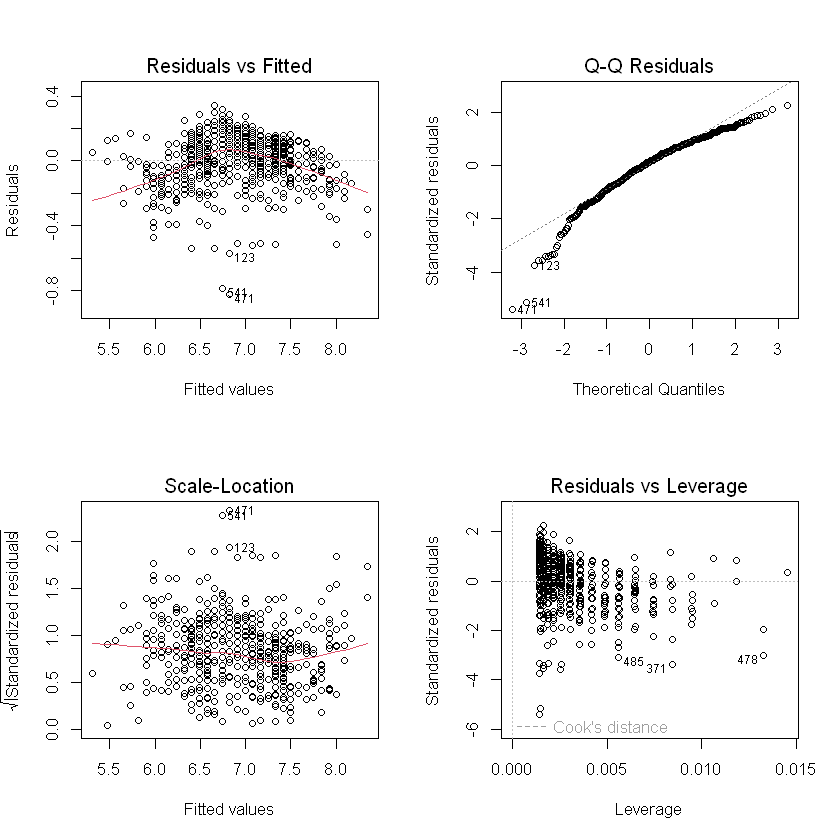

In [21]:
par(mfrow = c(2, 2))
plot(modelo_valor)
par(mfrow = c(1, 1))

In [22]:
residuos <- residuals(modelo_valor)
cooks <- cooks.distance(modelo_valor)
limiar_cook <- 4 / nrow(df)

diagnosticos <- data.frame(
  R2 = r2,
  R2_ajustado = r2_ajustado,
  RMSE_na_escala_log10 = sqrt(mean(residuos^2)),
  Distancia_Cook_maxima = max(cooks),
  Limiar_Cook_4_sobre_n = limiar_cook,
  Numero_acima_limiar_Cook = sum(cooks > limiar_cook),
  check.names = FALSE
)

round(diagnosticos, 4)

cat(sprintf(
  "\nForam encontradas %d observações com distância de Cook acima de 4/n (%.5f).\n",
  sum(cooks > limiar_cook),
  limiar_cook
))
cat(
  "Esses casos devem ser inspecionados como potenciais pontos influentes; o critério não implica exclusão automática.\n"
)

R2,R2_ajustado,RMSE_na_escala_log10,Distancia_Cook_maxima,Limiar_Cook_4_sobre_n,Numero_acima_limiar_Cook
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.9168,0.9167,0.1527,0.0605,0.0056,37



Foram encontradas 37 observações com distância de Cook acima de 4/n (0.00557).
Esses casos devem ser inspecionados como potenciais pontos influentes; o critério não implica exclusão automática.


### Síntese dos diagnósticos

O modelo apresenta relação linear muito forte na escala escolhida, coerente com a correlação observada na Fase 1. O \(R^2\) do modelo simples é aproximadamente o quadrado daquela correlação, isto é, cerca de **0,917**: aproximadamente **91,7% da variação de `log10(value_euro)`** é explicada por `overall_rating`.

Os gráficos diagnósticos devem ser avaliados visualmente após a execução do notebook. Pequenos desvios de normalidade ou alguns pontos influentes são esperados em uma base real de jogadores, especialmente nos extremos de avaliação e de valor de mercado. A presença de pontos influentes não invalida automaticamente o modelo, mas recomenda cautela ao extrapolar para jogadores muito diferentes dos observados.

## 13. Três manchetes de efeito

### Manchete 1 — **“Reputação internacional alta é exceção: menos de 1 em cada 5 jogadores está nos níveis 3 a 5.”**

**Resultado que sustenta a manchete:** na Fase 1, 133 dos 718 jogadores apresentaram `international_reputation(1-5)` igual a 3, 4 ou 5, correspondendo a aproximadamente **18,52%** da base. A seção de probabilidades desta fase trata esse mesmo resultado como \(P(B)\).

**Associação com a manchete:** dizer “menos de 1 em cada 5” traduz 18,52% para uma linguagem mais acessível, sem alterar o conteúdo estatístico.

---

### Manchete 2 — **“Quanto maior a nota, maior o preço: o overall acompanha quase toda a variação do valor de mercado em escala logarítmica.”**

**Resultado que sustenta a manchete:** a Fase 1 encontrou correlação de aproximadamente **0,9575** entre `overall_rating` e `log10(value_euro)`. Na regressão simples desta fase, isso corresponde a \(R^2\) de aproximadamente **0,917**, ou **91,7% da variação de `log10(value_euro)` explicada por `overall_rating`**.

**Associação com a manchete:** a frase comunica a associação muito forte entre avaliação geral e valor de mercado. Ela não afirma causalidade; descreve o padrão observado na base.

---

### Manchete 3 — **“A idade média fica abaixo dos 27 anos; já 78 kg continua compatível com o peso médio dos jogadores.”**

**Resultado que sustenta a manchete:** para `age`, o teste bilateral compara a média observada, próxima de 26,57, com 27 e rejeita \(H_0\) ao nível de 5%. Para `weight_kgs`, a média próxima de 77,67 é comparada com 78 e \(H_0\) não é rejeitada.

**Associação com a manchete:** a frase transforma duas decisões de testes de hipóteses em linguagem cotidiana: os dados oferecem evidência de que a média de idade difere de 27, mas não oferecem evidência suficiente para considerar o peso médio diferente de 78 kg.

## 14. Conclusões da Fase 2

1. As probabilidades empíricas mostraram como a chance de um `overall_rating` elevado pode mudar quando condicionamos a análise à reputação internacional.
2. Os intervalos de confiança quantificaram a incerteza associada às médias de `overall_rating` e `age`.
3. Os testes de hipóteses produziram conclusões distintas para `age` e `weight_kgs`, ilustrando a diferença entre rejeitar e não rejeitar uma hipótese nula.
4. A regressão de `log10(value_euro)` em função de `overall_rating` confirmou a forte associação já observada na Fase 1 e permitiu interpretar o efeito do `overall_rating` em termos multiplicativos.
5. Os diagnósticos do modelo foram incluídos para verificar linearidade, distribuição dos resíduos, homocedasticidade e possíveis observações influentes.
6. As três manchetes finais traduzem resultados quantitativos das duas fases para uma linguagem mais direta, mantendo a ligação explícita com as evidências estatísticas.

## Referências

- Base FIFA oficial do projeto: <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv>
- Dicionário de variáveis: <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_Dicionario.xlsx>
- Exemplo indicado no enunciado (Google Colab): <https://colab.research.google.com/drive/15xlP2Aonze12SAsBruHrHpcqOy-AeZYA?usp=sharing>
- Automobile Data Set indicado no enunciado: <https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data>